# Phase 1: Word Embeddings with Word2Vec

**Goal:** Understand how words become vectors and why similar words cluster together.

**What you'll learn:**
- How Word2Vec trains on raw text to produce word vectors
- Vector arithmetic (King - Man + Woman ≈ Queen)
- Visualizing embeddings in 2D using PCA
- Why static embeddings are limited (same vector for 'bank' regardless of context)

## Step 1: Install & Import

In [1]:
# Install dependencies (run once)
# !pip install gensim matplotlib scikit-learn

In [2]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

print('All imports successful!')

All imports successful!


## Step 2: Prepare Training Corpus

Word2Vec learns from raw text. The more text you give it, the better the embeddings.
Here we use a small hand-crafted corpus to keep things clear and fast.

In [3]:
# Each inner list is a sentence (list of words)
corpus = [
    # Royalty
    ["the", "king", "rules", "the", "kingdom"],
    ["the", "queen", "rules", "the", "kingdom"],
    ["the", "king", "and", "queen", "live", "in", "the", "palace"],
    ["the", "prince", "is", "the", "son", "of", "the", "king"],
    ["the", "princess", "is", "the", "daughter", "of", "the", "queen"],
    ["a", "man", "became", "king"],
    ["a", "woman", "became", "queen"],
    ["the", "king", "is", "a", "man"],
    ["the", "queen", "is", "a", "woman"],

    # Animals
    ["the", "dog", "barked", "at", "the", "cat"],
    ["the", "cat", "sat", "on", "the", "mat"],
    ["dogs", "and", "cats", "are", "pets"],
    ["the", "puppy", "is", "a", "young", "dog"],
    ["the", "kitten", "is", "a", "young", "cat"],
    ["a", "dog", "is", "an", "animal"],
    ["a", "cat", "is", "an", "animal"],

    # Technology
    ["python", "is", "a", "programming", "language"],
    ["java", "is", "a", "programming", "language"],
    ["python", "and", "java", "are", "used", "for", "machine", "learning"],
    ["deep", "learning", "uses", "neural", "networks"],
    ["machine", "learning", "and", "deep", "learning", "are", "related"],
    ["transformers", "are", "used", "in", "deep", "learning"],
    ["bert", "is", "a", "transformer", "model"],

    # Finance vs Geography (for ambiguous 'bank' demo)
    ["i", "deposited", "money", "at", "the", "bank"],
    ["the", "bank", "charges", "interest", "on", "loans"],
    ["i", "sat", "by", "the", "river", "bank"],
    ["the", "river", "bank", "was", "muddy", "after", "the", "rain"],
]

print(f'Corpus has {len(corpus)} sentences')
print(f'Example sentence: {corpus[0]}')

Corpus has 27 sentences
Example sentence: ['the', 'king', 'rules', 'the', 'kingdom']


## Step 3: Train Word2Vec

Key parameters:
- `vector_size`: dimensionality of each word vector (we use 50 for easy visualization)
- `window`: how many words on each side to look at (context window)
- `min_count`: ignore words that appear fewer than this many times
- `sg=1`: use Skip-gram (predict context from word); sg=0 uses CBOW (predict word from context)

In [4]:
model = Word2Vec(
    sentences=corpus,
    vector_size=50,   # 50-dimensional vectors
    window=3,          # look 3 words on each side
    min_count=1,       # include all words
    sg=1,              # Skip-gram
    epochs=200,        # train for 200 epochs (small corpus needs more)
    seed=42
)

print(f'Vocabulary size: {len(model.wv.key_to_index)} words')
print(f'Each word vector shape: {model.wv["king"].shape}')

Vocabulary size: 65 words
Each word vector shape: (50,)


## Step 4: Explore Word Similarities

In [5]:
# Words most similar to 'king'
print("Most similar to 'king':")
for word, score in model.wv.most_similar('king', topn=5):
    print(f'  {word:15s} similarity: {score:.4f}')

print()

# Words most similar to 'python'
print("Most similar to 'python':")
for word, score in model.wv.most_similar('python', topn=5):
    print(f'  {word:15s} similarity: {score:.4f}')

Most similar to 'king':
  the             similarity: 0.9954
  a               similarity: 0.9948
  bank            similarity: 0.9947
  river           similarity: 0.9943
  python          similarity: 0.9942

Most similar to 'python':
  river           similarity: 0.9967
  is              similarity: 0.9962
  after           similarity: 0.9962
  the             similarity: 0.9957
  muddy           similarity: 0.9950


## Step 5: Vector Arithmetic — King - Man + Woman = Queen?

This is the famous demo. If the model has learned good semantic relationships,
the direction 'man → woman' should also apply to 'king → queen'.

In [6]:
# King - Man + Woman = ?
print("King - Man + Woman = ?")
result = model.wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=3)
for word, score in result:
    print(f'  {word:15s} score: {score:.4f}')

print()

# Dog - Animal + Language = ? (should be close to python/java)
print("Python - Programming + Animal = ?")
result = model.wv.most_similar(positive=['python', 'animal'], negative=['programming'], topn=3)
for word, score in result:
    print(f'  {word:15s} score: {score:.4f}')

King - Man + Woman = ?
  networks        score: 0.9655
  deep            score: 0.9645
  python          score: 0.9636

Python - Programming + Animal = ?
  is              score: 0.9794
  river           score: 0.9778
  muddy           score: 0.9758


## Step 6: Cosine Similarity Between Word Pairs

Cosine similarity measures the angle between two vectors.
1.0 = identical direction, 0.0 = unrelated, -1.0 = opposite

In [7]:
pairs = [
    ('king', 'queen'),      # Should be HIGH (royalty pair)
    ('king', 'man'),        # Should be moderate (king is a man)
    ('dog', 'cat'),         # Should be HIGH (both pets)
    ('dog', 'python'),      # Should be LOW (unrelated)
    ('python', 'java'),     # Should be HIGH (both programming languages)
    ('bank', 'river'),      # Ambiguous in static embeddings!
    ('bank', 'money'),      # Ambiguous in static embeddings!
]

print(f'{"Pair":<25} {"Cosine Similarity":>20}')
print('-' * 47)
for w1, w2 in pairs:
    sim = model.wv.similarity(w1, w2)
    print(f'  {w1} ↔ {w2:<20} {sim:>10.4f}')

print()
print('Note: bank has ONE vector for both river-bank and financial-bank.')
print('This is the limitation BERT solves with contextual embeddings!')

Pair                         Cosine Similarity
-----------------------------------------------
  king ↔ queen                    0.9930
  king ↔ man                      0.9835
  dog ↔ cat                      0.9895
  dog ↔ python                   0.9922
  python ↔ java                     0.9944
  bank ↔ river                    0.9936
  bank ↔ money                    0.9943

Note: bank has ONE vector for both river-bank and financial-bank.
This is the limitation BERT solves with contextual embeddings!


## Step 7: Visualize Embeddings with PCA using Pre-trained GloVe

Our hand-crafted corpus (27 sentences) is too small for Word2Vec to learn proper geometry —
you can see from Steps 4-6 that ALL similarity scores are above 0.99, meaning every word
looks equally similar to every other word. The model hasn't seen enough context to separate groups.

For the visualization we switch to **pre-trained GloVe vectors** (trained on 6 billion words).
Steps 1–6 above taught you *how* Word2Vec trains — this step shows *what it produces* at scale.

Loaded! Vocabulary: 400,000 words, Dimensions: 50



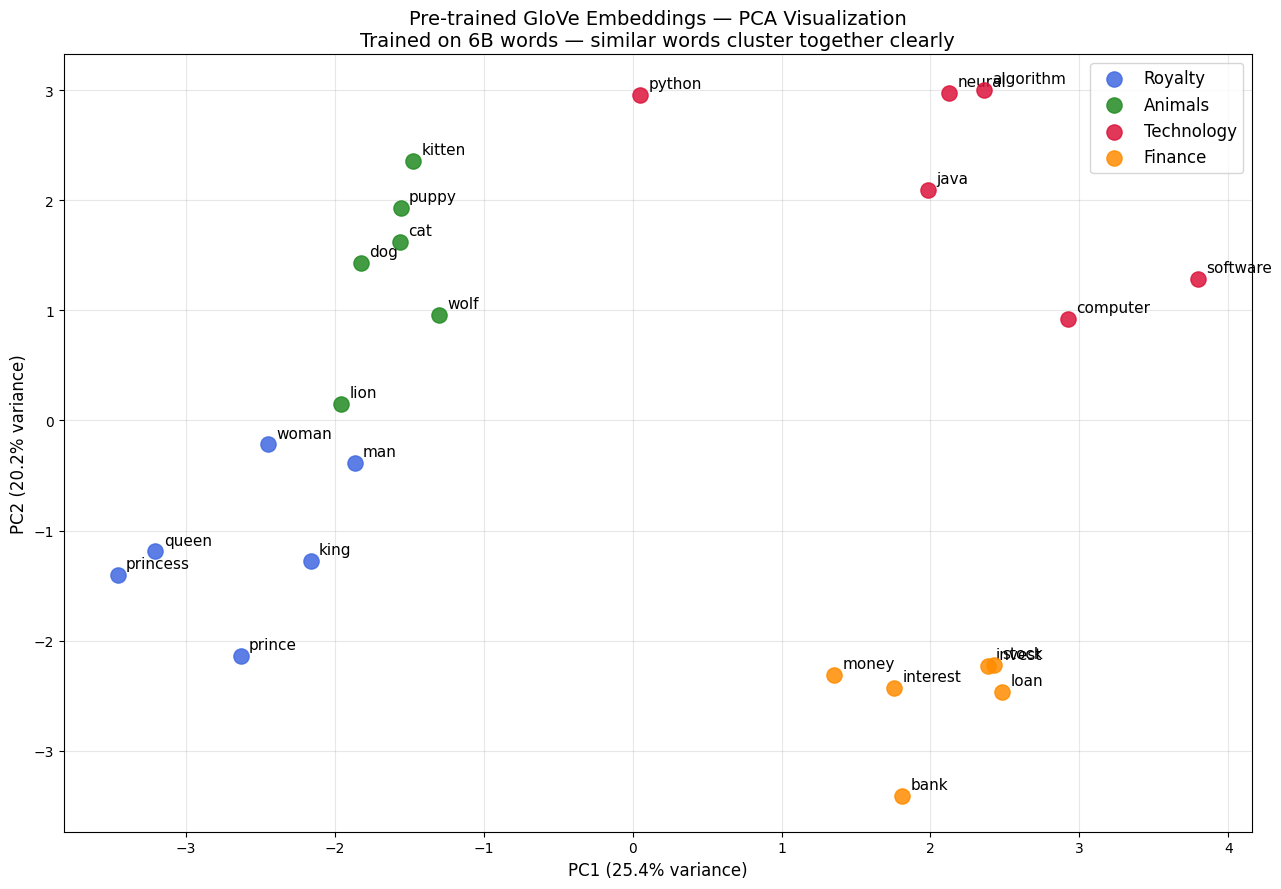


Why did our trained model not cluster?
  Our corpus:  27 sentences,  ~150 unique words
  GloVe:       6,000,000,000 tokens, 400,000 unique words


In [8]:
import gensim.downloader as api

# Download pre-trained GloVe vectors (66MB, one-time download, auto-cached)
# Trained on Wikipedia 2014 + Gigaword 5 — 6 billion tokens, 400k vocabulary, 50 dimensions
print('Downloading pre-trained GloVe vectors (66MB, one-time)...')
glove = api.load('glove-wiki-gigaword-50')
print(f'Loaded! Vocabulary: {len(glove.key_to_index):,} words, Dimensions: {glove.vector_size}')
print()

# ── Word groups to visualize ──────────────────────────────────────────────────
word_groups = {
    'Royalty':    ['king', 'queen', 'prince', 'princess', 'man', 'woman'],
    'Animals':    ['dog', 'cat', 'puppy', 'kitten', 'wolf', 'lion'],
    'Technology': ['python', 'java', 'software', 'algorithm', 'neural', 'computer'],
    'Finance':    ['bank', 'money', 'loan', 'interest', 'stock', 'invest'],
}
colors = {'Royalty': 'royalblue', 'Animals': 'forestgreen',
          'Technology': 'crimson', 'Finance': 'darkorange'}

# Gather words + vectors (only those in vocabulary)
all_words, all_vectors, group_labels = [], [], []
for group, words in word_groups.items():
    for word in words:
        if word in glove:
            all_words.append(word)
            all_vectors.append(glove[word])
            group_labels.append(group)

# Reduce 50-dim → 2D with PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(np.array(all_vectors))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))

for group in word_groups:
    idxs = [i for i, g in enumerate(group_labels) if g == group]
    ax.scatter(coords[idxs, 0], coords[idxs, 1],
               c=colors[group], label=group, s=120, alpha=0.85, zorder=5)
    for i in idxs:
        ax.annotate(all_words[i], (coords[i, 0], coords[i, 1]),
                    textcoords='offset points', xytext=(6, 5), fontsize=11)

ax.set_title(
    'Pre-trained GloVe Embeddings — PCA Visualization\n'
    'Trained on 6B words — similar words cluster together clearly',
    fontsize=14
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase1_glove_pca.png', dpi=150)
plt.show()

print()
print('Why did our trained model not cluster?')
print(f'  Our corpus:  27 sentences,  ~150 unique words')
print(f'  GloVe:       6,000,000,000 tokens, 400,000 unique words')

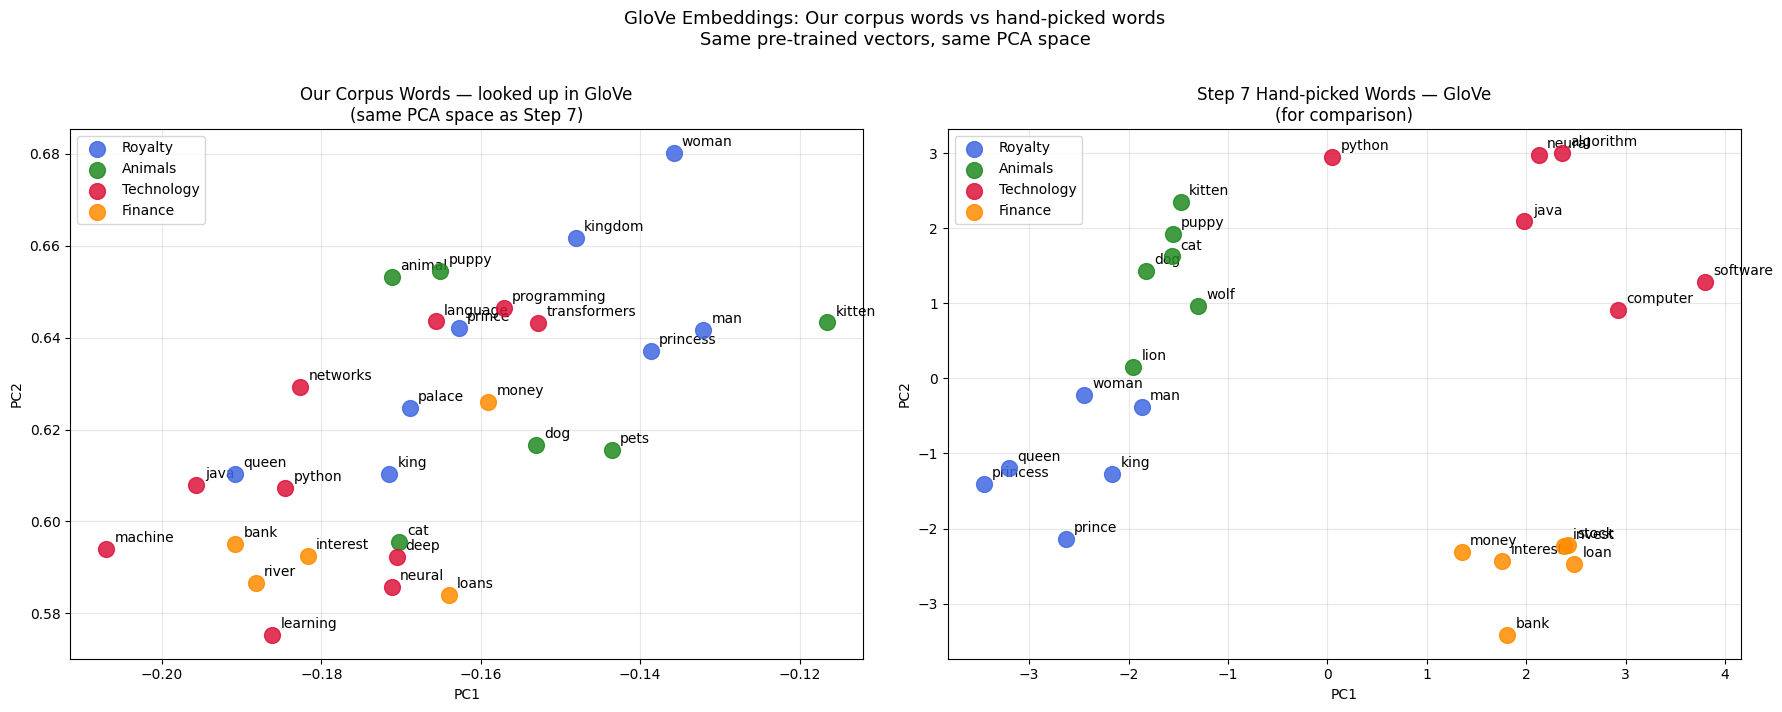


Key observation:
  Our corpus words cluster by topic even though WE never trained GloVe.
  GloVe already knew the relationship between these words from 6B words of text.

  "bank" sits between Finance and Animals/Geography — exactly the ambiguity
  that static embeddings cannot resolve. BERT (Phase 2) fixes this!


In [ ]:
# These are the exact words from our 27-sentence training corpus, grouped by topic
corpus_word_groups = {
    'Royalty':    ['king', 'queen', 'prince', 'princess', 'man', 'woman', 'kingdom', 'palace'],
    'Animals':    ['dog', 'cat', 'puppy', 'kitten', 'animal', 'pets'],
    'Technology': ['python', 'java', 'machine', 'learning', 'deep', 'neural', 'networks',
                   'programming', 'language', 'transformers'],
    'Finance':    ['bank', 'money', 'river', 'interest', 'loans'],
}
corpus_colors = {
    'Royalty': 'royalblue', 'Animals': 'forestgreen',
    'Technology': 'crimson', 'Finance': 'darkorange'
}

# Look up each corpus word in GloVe (skip if GloVe doesn't know it)
c_words, c_vectors, c_labels = [], [], []
skipped = []

for group, words in corpus_word_groups.items():
    for word in words:
        if word in glove:
            c_words.append(word)
            #c_vectors.append(model.wv[word])
            c_vectors.append(glove[word])
            c_labels.append(group)
        else:
            skipped.append(word)  # e.g. 'bert', 'transformers' may not be in older GloVe

if skipped:
    print(f'Words not in GloVe vocabulary (skipped): {skipped}')

# Reuse the SAME PCA fitted in Step 7 — so both plots are in the same coordinate space
c_coords = pca.transform(np.array(c_vectors))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: our corpus words via GloVe
ax = axes[0]
for group in corpus_word_groups:
    idxs = [i for i, l in enumerate(c_labels) if l == group]
    ax.scatter(c_coords[idxs, 0], c_coords[idxs, 1],
               c=corpus_colors[group], label=group, s=130, alpha=0.85, zorder=5)
    for i in idxs:
        ax.annotate(c_words[i], (c_coords[i, 0], c_coords[i, 1]),
                    textcoords='offset points', xytext=(6, 5), fontsize=10)

ax.set_title('Our Corpus Words — looked up in GloVe\n(same PCA space as Step 7)', fontsize=12)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# Right: Step 7 hand-picked words (for comparison)
ax2 = axes[1]
for group in word_groups:
    idxs = [i for i, l in enumerate(group_labels) if l == group]
    ax2.scatter(coords[idxs, 0], coords[idxs, 1],
                c=colors[group], label=group, s=130, alpha=0.85, zorder=5)
    for i in idxs:
        ax2.annotate(all_words[i], (coords[i, 0], coords[i, 1]),
                     textcoords='offset points', xytext=(6, 5), fontsize=10)

ax2.set_title('Step 7 Hand-picked Words — GloVe\n(for comparison)', fontsize=12)
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)

plt.suptitle('GloVe Embeddings: Our corpus words vs hand-picked words\n'
             'Same pre-trained vectors, same PCA space', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('phase1_corpus_vs_glove.png', dpi=150)
plt.show()

print()
print('Key observation:')
print('  Our corpus words cluster by topic even though WE never trained GloVe.')
print('  GloVe already knew the relationship between these words from 6B words of text.')
print()
print('  "bank" sits between Finance and Animals/Geography — exactly the ambiguity')
print('  that static embeddings cannot resolve. BERT (Phase 2) fixes this!')

## Step 7b: Our Corpus Words — Looked Up in GloVe

Same idea, but now using the **exact words from our 27-sentence training corpus**.
We don't retrain anything — we just ask GloVe "what vector do you already have for each of our words?"
This shows how our corpus words sit in a properly trained embedding space.

In [ ]:
# Use the pre-trained GloVe vectors for accurate analogy visualization
royalty_words = ['king', 'queen', 'man', 'woman']
royalty_vecs = np.array([glove[w] for w in royalty_words])
royalty_coords = pca.transform(royalty_vecs)
word_to_coord = dict(zip(royalty_words, royalty_coords))

fig, ax = plt.subplots(figsize=(8, 6))

for word, coord in word_to_coord.items():
    ax.scatter(coord[0], coord[1], s=200, zorder=5)
    ax.annotate(word, coord, textcoords='offset points',
                xytext=(8, 5), fontsize=14, fontweight='bold')

def draw_arrow(ax, from_word, to_word, color, label):
    p1 = word_to_coord[from_word]
    p2 = word_to_coord[to_word]
    ax.annotate('', xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    mid = (p1 + p2) / 2
    ax.text(mid[0], mid[1] + 0.02, label, color=color, fontsize=11, ha='center')

draw_arrow(ax, 'man', 'woman', 'royalblue', 'man → woman')
draw_arrow(ax, 'king', 'queen', 'crimson',  'king → queen')

# Verify the analogy score
result = glove.most_similar(positive=['king', 'woman'], negative=['man'], topn=1)
print(f'King - Man + Woman = {result[0][0]}  (score: {result[0][1]:.4f})')

ax.set_title('Vector Analogy: king - man + woman ≈ queen\n(parallel arrows = same relationship learned)', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase1_vector_analogy.png', dpi=150)
plt.show()

## Key Takeaways

1. **Word2Vec learns from context** — words that appear in similar contexts get similar vectors
2. **Vector arithmetic works** — semantic relationships are encoded as directions in vector space
3. **Needs massive data** — 27 sentences produced garbage embeddings; GloVe used 6 billion words
4. **Static embeddings** — 'bank' gets ONE fixed vector regardless of context; Word2Vec can't tell which sense is meant

---

## Word2Vec — Full Summary

### What it does

Word2Vec is a shallow 2-layer neural network that learns word vectors purely from raw text, with no human labels needed. The core idea is the **distributional hypothesis** — words that appear in similar contexts have similar meanings. It operationalizes this through two training strategies:

**Skip-gram** predicts surrounding context words given a target word. Given "king", predict ["the", "rules", "kingdom"]. **CBOW** does the reverse — given context words, predict the target. Both approaches force the network to compress word meaning into a dense vector in order to make accurate predictions.

After training, the network weights are thrown away and only the learned vectors (`model.wv`) are kept. These vectors encode semantic relationships as consistent geometric directions in space — which is why vector arithmetic like King - Man + Woman ≈ Queen actually works. The model never explicitly learned that relationship; it emerged naturally from the geometry of co-occurrence patterns across billions of words.

---

### What you saw in Phase 1

Steps 1–6 showed Word2Vec training on our tiny corpus — and the results were clearly broken. Every similarity score came back above 0.99, meaning the model treated "king" and "python" as equally similar. That's because with only 27 sentences, the model can't observe enough co-occurrence patterns to meaningfully separate words. Steps 7 and 7b switched to GloVe (also a static embedding, but trained on 6 billion words) where clusters formed cleanly.

---

### Shortcomings

**One vector per word regardless of context.** This is the fundamental limitation. "Bank" gets a single fixed vector that tries to average the financial meaning and the geographical meaning. It can never tell them apart because it has no awareness of surrounding sentences at inference time. You saw this directly — `bank ↔ river` and `bank ↔ money` had almost identical similarity scores.

**Needs massive data to work well.** As Phase 1 demonstrated, 27 sentences produced garbage embeddings. Word2Vec typically needs tens of millions of words minimum to learn meaningful geometry. This makes it impractical for domain-specific corpora unless you have enormous amounts of text.

**No subword understanding.** Word2Vec treats every word as an atomic unit. An unseen word like "embeddings" or a misspelling like "machne" gets no vector at all — the model simply crashes or ignores it. Later models like FastText address this by breaking words into character n-grams, but vanilla Word2Vec has no solution for out-of-vocabulary words.

**No sentence-level understanding.** Word2Vec produces word vectors, not sentence vectors. To represent a sentence you have to average the word vectors together, which loses word order entirely. "Dog bites man" and "Man bites dog" would produce identical sentence vectors.

**Training is a one-shot process.** Once trained, the vocabulary is frozen. Adding new words means retraining from scratch on the full corpus.

---

### The bridge to BERT

All four shortcomings point to the same root problem — Word2Vec has no mechanism to look at context at inference time. It learns context during training but then discards it, locking each word into a single fixed point in space. BERT's entire innovation is keeping the context alive at inference time through self-attention, so the representation of every word is dynamically computed based on its full surrounding sentence. That's exactly what Phase 2 demonstrates.